# H3_3: Árbol de decisión para regresión
## Estimación del acceso municipal a Internet en La Paz

**Materia:** Minería de Datos — UNIFRANZ, gestión 2026-2.  
**Docente:** Enrique Alejandro Laurel Cossio.  
**Responsable de H3_3:** Cristopher Iori Lazcano Gutierrez.  
**Fuente:** Censo de Población y Vivienda 2024, Instituto Nacional de Estadística de Bolivia.

Este análisis continúa el proyecto grupal de conectividad. El EDA describe las
brechas de acceso; H3_1 y H3_2 clasifican viviendas según tengan o no Internet.
H3_3 aplica el árbol de regresión estudiado en clase a una pregunta numérica:
**¿qué porcentaje de viviendas de un municipio declara acceso a Internet,
según sus características censales?** Cada fila del modelo representa un municipio.

Las tasas se refieren a 2024. El modelo permite estudiar asociaciones entre
condiciones municipales y conectividad, y revisar dónde la estimación es menos
precisa. La priorización efectiva de infraestructura requiere también información
de cobertura, costos y calidad del servicio que este censo no mide.

### 1. Fuentes y ejecución

- [Bases CSV oficiales del Censo 2024](https://cpv2024.ine.gob.bo/index.php/principal/descargas/).
- [H3_3 del docente](https://github.com/ealaurel/MINERIA_DATOS_2026_2/blob/main/h3_3_Arboles_de_decisi%C3%B3n_regresion.ipynb): árbol de regresión, importancia, visualización, MSE, R² y búsqueda de parámetros.
- [Proyecto grupal](https://github.com/lpzealexjoelquispeti-dot/Mineria-de-Datos-Internet): universo TIC, diccionario y resultados municipales del EDA.

Desde la raíz, instalar `requirements.txt` y ejecutar
`python scripts/descargar_datos_censo.py`. El descargador verifica el ZIP oficial y
las huellas de Vivienda, diccionario y cuestionario frente a las fuentes del grupo.
Después se puede ejecutar este notebook desde la raíz o desde `notebooks/`.
La copia departamental se genera automáticamente si todavía no existe.

El notebook utiliza funciones de `src/decision_tree_regression.py` para que la
ejecución por script y por Jupyter comparta las mismas reglas. Las nuevas salidas
se guardan exclusivamente en `outputs/h3_3/`.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import joblib
from IPython.display import display, Markdown, Image
from sklearn.tree import export_text

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'src/decision_tree_regression.py').is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from src.decision_tree_regression import (
    TARGET, FEATURES, FEATURE_LABELS, preparar_dataset, dividir_municipios,
    entrenar, guardar_resultados, explicar_prediccion,
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')
def texto(message):
    display(Markdown(message))

### 2. Datos, unidad de análisis y calidad

Se reutiliza el universo del EDA: viviendas particulares de tipos 1 a 6,
ocupadas con personas presentes (condición 0 o 1). Los registros fuera de ese
universo se excluyen. Los nombres municipales se obtienen del catálogo del
diccionario, validando los códigos antes de agregarlos.

La carga selecciona La Paz a partir del CSV de Vivienda leído en bloques. Se
comprueban las fuentes y se reconcilia cada tasa y denominador con
`outputs/tablas/municipios.csv`. La tabla agregada conserva registros, accesos,
respuestas sin acceso y respuestas sin especificar.

In [2]:
datos = preparar_dataset(RAIZ)
tabla = datos.table
display(pd.DataFrame([datos.audit]).drop(columns=['fuentes_verificadas', 'faltantes_municipales']))
display(pd.DataFrame(datos.audit['fuentes_verificadas']).T)
display(tabla.head())

,fuente,registros_nacionales,registros_lapaz,universo_tic,municipios,target_sin_especificar,tasa_departamental_pct,tasas_y_denominadores_coinciden_con_eda
0,https://cpv2024.ine.gob.bo/index.php/principal...,4490488,1334496,1069838,87,30497,69.955,True


,sha256,bytes
Vivienda_CPV-2024.csv,f3cef44bcf103978734e86adf2c8c147a89adcb7146c78...,490862565
Diccionario de variables CPV 2024.xlsx,20e1f074145b8277ad18a71bc180a3e2f89f0b38fc9760...,204479


,municipio_codigo,municipio,universo,algun_si,algun_no,algun_sin_especificar,pct_algun,pct_sin_especificar,pct_urbanas,pct_computadora,pct_celular,pct_red_electrica,pct_3_o_mas_habitaciones,promedio_personas
0,20101,Nuestra Señora de La Paz,250931,225425,21482,4024,89.835,1.604,98.799,68.311,95.750,98.141,59.020,2.910
1,20102,Palca,7585,3956,3325,304,52.156,4.008,0.000,7.159,82.610,85.194,30.310,2.855
2,20103,Mecapaca,6849,4600,2083,166,67.163,2.424,0.000,27.551,89.356,90.042,47.277,2.972
3,20104,Achocalla,16297,11222,4419,656,68.859,4.025,88.814,25.563,87.844,82.205,37.400,2.743
4,20105,El Alto,297898,250592,41606,5700,84.120,1.913,99.939,48.256,94.079,96.387,52.455,2.946


In [3]:
display(datos.quality)
display(tabla[FEATURES + [TARGET]].isna().sum().rename('Faltantes municipales').to_frame())
print('Municipios duplicados:', tabla['municipio_codigo'].duplicated().sum())
display(tabla[FEATURES + [TARGET]].describe())

,variable,registros,sin_especificar,invalidos_o_vacios
0,urbrur,1069838,0,0
1,v19c_compu,1069838,30508,0
2,v19d_celular,1069838,30525,0
3,v09_energia,1069838,0,0
4,v13_habitac,1069838,0,0
5,tot_pers,1069838,0,0


,Faltantes municipales
pct_urbanas,0
pct_computadora,0
pct_celular,0
pct_red_electrica,0
pct_3_o_mas_habitaciones,0
promedio_personas,0
pct_algun,0


Municipios duplicados: 0


,pct_urbanas,pct_computadora,pct_celular,pct_red_electrica,pct_3_o_mas_habitaciones,promedio_personas,pct_algun
count,87.000,87.000,87.000,87.000,87.000,87.000,87.000
mean,15.791,11.340,80.215,74.430,28.890,2.698,49.387
std,23.853,9.151,5.457,11.448,8.925,0.477,11.999
min,0.000,1.905,65.208,26.349,11.464,2.006,24.327
25%,0.000,6.199,76.472,69.593,22.797,2.394,40.907
50%,0.000,8.735,80.339,75.767,28.542,2.601,48.228
75%,27.885,13.415,83.539,81.967,34.517,2.905,56.284
max,99.939,68.311,95.750,98.141,59.020,4.971,89.835


Los códigos `9 = Sin especificar` de tenencia de computadora o celular se
cuantifican y conservan en el denominador de cada proporción. Por eso una tasa de
respuestas Sí no implica que todo el porcentaje restante sea No. La suma de
personas usa los valores numéricos válidos en viviendas con personas presentes.
Si algún promedio municipal resultara ausente, el pipeline lo imputaría con la
mediana aprendida exclusivamente en cada conjunto de entrenamiento.

El diccionario codifica `8` habitaciones como «Ocho o más». Se utiliza el porcentaje
con **tres o más habitaciones** en vez de calcular un promedio que trataría ese
valor como un conteo exacto.

### 3. Métrica del proyecto y variable objetivo

La métrica principal del grupo sigue siendo el porcentaje de viviendas con
acceso declarado a Internet:

\[
\text{Acceso municipal (\%)} = 100\times
\frac{\text{viviendas aplicables con }v19e\_f=1}
{\text{total de viviendas del universo TIC municipal}}.
\]

En H3_3 esa tasa es también el objetivo numérico `pct_algun`, en escala de 0 a 100.
El código 9 de Internet queda en el denominador, igual que en el EDA. No se suman
acceso fijo y móvil porque una vivienda puede tener ambos. Se usa la combinada
oficial `v19e_f`.

La tasa departamental pondera por viviendas. El promedio simple municipal da el
mismo peso a cada municipio; ambos responden a preguntas diferentes.

In [4]:
accesos = int(tabla['algun_si'].sum())
universo = int(tabla['universo'].sum())
tasa_departamental = accesos / universo * 100
texto(f'**Tasa departamental:** {accesos:,} / {universo:,} × 100 = '
      f'**{tasa_departamental:.2f} %**. Hay **{len(tabla)} municipios**. '
      f'La media municipal sin ponderar es **{tabla[TARGET].mean():.2f} %**.')
display(tabla[['municipio', 'universo', 'algun_si', 'algun_no',
               'algun_sin_especificar', TARGET]].head())

**Tasa departamental:** 748,401 / 1,069,838 × 100 = **69.95 %**. Hay **87 municipios**. La media municipal sin ponderar es **49.39 %**.

,municipio,universo,algun_si,algun_no,algun_sin_especificar,pct_algun
0,Nuestra Señora de La Paz,250931,225425,21482,4024,89.835
1,Palca,7585,3956,3325,304,52.156
2,Mecapaca,6849,4600,2083,166,67.163
3,Achocalla,16297,11222,4419,656,68.859
4,El Alto,297898,250592,41606,5700,84.120


### 4. Predictores y prevención de fuga de información

Los predictores describen equipamiento, urbanización y condiciones de vivienda.
Son proporciones municipales o un promedio, calculados a partir de las mismas
viviendas aplicables. El celular no equivale a declarar Internet móvil.

Se excluyen el acceso fijo, móvil y combinado, las tasas de no acceso, los
conteos con Internet y las predicciones de H3_1/H3_2. Esas columnas contienen o
derivan de la respuesta. Los códigos y nombres municipales se usan para
identificar resultados y separar observaciones, sin entrar al modelo.

In [5]:
display(pd.DataFrame({'Predictor': FEATURES, 'Interpretación y unidad': list(FEATURE_LABELS.values())}))
X = tabla[FEATURES].copy()
y = tabla[TARGET].copy()
print('X:', X.shape, '| y:', y.shape)

,Predictor,Interpretación y unidad
0,pct_urbanas,Viviendas urbanas (%)
1,pct_computadora,"Con computadora, laptop o tablet (%)"
2,pct_celular,Con teléfono celular (%)
3,pct_red_electrica,Con electricidad de red pública (%)
4,pct_3_o_mas_habitaciones,Con 3 o más habitaciones (%)
5,promedio_personas,Personas por vivienda (promedio)


X: (87, 6) | y: (87,)


### 5. Separación de entrenamiento y prueba

Se utiliza 70 % para entrenamiento y 30 % para prueba, como en el ejemplo de
regresión del docente, con `random_state=777` para conservar la semilla del
proyecto. Se separan **municipios completos**. No se estratifica una variable
continua como si fueran clases.

Las características de un municipio se calculan con sus propias viviendas.
La imputación y la selección de hiperparámetros se ajustan únicamente sobre
municipios de entrenamiento. Los municipios de prueba se reservan para evaluar
el modelo seleccionado. Cada municipio recibe el mismo peso.

In [6]:
X_train, X_test, y_train, y_test = dividir_municipios(tabla)
assert set(X_train.index).isdisjoint(X_test.index)
print('Entrenamiento:', len(X_train), '| Prueba:', len(X_test))
print('Municipios compartidos:', len(set(X_train.index) & set(X_test.index)))
display(tabla.loc[X_test.index, ['municipio_codigo', 'municipio']].sort_values('municipio_codigo'))

Entrenamiento: 60 | Prueba: 27
Municipios compartidos: 0


,municipio_codigo,municipio
1,20102,Palca
3,20104,Achocalla
5,20201,Achacachi
8,20204,Santiago de Huata
9,20205,Huatajata
11,20301,Corocoro
12,20302,Caquiaviri
17,20307,Nazacara de Pacajes
19,20401,Puerto Acosta
22,20404,Humanata


### 6. Árbol inicial, comparación básica y ajuste

Un árbol de regresión divide los municipios mediante condiciones sobre los
predictores. Cada hoja predice la **media de acceso de los municipios de
entrenamiento** que llegaron a esa hoja.

Se entrenan tres modelos: una referencia que siempre predice el promedio de
entrenamiento; un árbol inicial de profundidad 2, como el docente; y un árbol
ajustado. La búsqueda explora profundidades 1–19, `min_samples_split` 2–9 y
`min_samples_leaf` 1–4. Las 608 combinaciones se comparan con cinco particiones
de validación cruzada dentro de entrenamiento, utilizando MSE.

`neg_mean_squared_error` utiliza el signo negativo porque scikit-learn maximiza
el puntaje. Al interpretar, se cambia de signo: **un MSE menor es mejor**.
El modelo final es `best_estimator_`; se aplican realmente los parámetros
encontrados. La selección se cierra antes de calcular las métricas de prueba.

In [7]:
# entrenar() realiza la búsqueda sobre train y evalúa la selección cerrada.
resultado = entrenar(datos)
busqueda = resultado['busqueda']
modelo = resultado['modelo']
print('Grilla:', busqueda.param_grid)
print('Validación cruzada:', busqueda.cv)
print('Mejores parámetros:', busqueda.best_params_)
print('MSE medio de validación:', -busqueda.best_score_)
display(resultado['grid'].head(10))

Grilla: {'modelo__max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], 'modelo__min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9], 'modelo__min_samples_leaf': [1, 2, 3, 4]}
Validación cruzada: KFold(n_splits=5, random_state=777, shuffle=True)
Mejores parámetros: {'modelo__max_depth': 7, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 7}
MSE medio de validación: 51.166268497394846


,param_modelo__max_depth,param_modelo__min_samples_split,param_modelo__min_samples_leaf,std_test_score,rank_test_score,mse_cv_pp2
581,19,7,1,25.058,1,51.166
517,17,7,1,25.058,1,51.166
293,10,7,1,25.058,1,51.166
357,12,7,1,25.058,1,51.166
485,16,7,1,25.058,1,51.166
421,14,7,1,25.058,1,51.166
453,15,7,1,25.058,1,51.166
261,9,7,1,25.058,1,51.166
389,13,7,1,25.058,1,51.166
229,8,7,1,25.058,1,51.166


### 7. Evaluación de entrenamiento y prueba

- **MAE:** error absoluto medio, en puntos porcentuales (pp).
- **RMSE:** raíz del MSE, en pp; penaliza más los errores grandes.
- **MSE:** promedio de errores al cuadrado, en pp².
- **R²:** desempeño frente a la media del conjunto evaluado; puede ser negativo.

Accuracy, F1 y matriz de confusión corresponden a clasificación. La tasa
continua de H3_3 se evalúa con errores numéricos. Los resultados de clasificación
del proyecto permanecen en los notebooks H3_1 y H3_2.

In [8]:
comparacion = resultado['comparacion'].set_index('modelo')
display(comparacion[['mse_cv_pp2', 'train_mae_pp', 'test_mae_pp',
                    'test_rmse_pp', 'test_mse_pp2', 'test_r2']])
fila_final = comparacion.loc['Árbol ajustado por CV']
fila_base = comparacion.loc['Promedio de entrenamiento']
cambio_mae = (fila_base['test_mae_pp'] - fila_final['test_mae_pp']) / fila_base['test_mae_pp'] * 100
texto(f'En los **{len(X_test)} municipios de prueba**, el árbol ajustado obtiene '
      f'**MAE = {fila_final["test_mae_pp"]:.2f} pp**, '
      f'**RMSE = {fila_final["test_rmse_pp"]:.2f} pp** y '
      f'**R² = {fila_final["test_r2"]:.3f}**. '
      f'El MAE de la referencia es **{fila_base["test_mae_pp"]:.2f} pp**. '
      f'La reducción relativa del MAE frente a esa referencia es **{cambio_mae:.1f} %** '
      f'en esta partición. Es una mejora del error predictivo medido; '
      f'no significa que haya aumentado el acceso real a Internet.')
texto(f'El MAE de entrenamiento del árbol es **{fila_final["train_mae_pp"]:.2f} pp**, '
      f'frente a **{fila_final["test_mae_pp"]:.2f} pp** en prueba. '
      f'La diferencia indica una capacidad de generalización limitada y posible '
      f'sobreajuste; no se afirma que el árbol lo haya eliminado.')

,mse_cv_pp2,train_mae_pp,test_mae_pp,test_rmse_pp,test_mse_pp2,test_r2
modelo,,,,,,
Promedio de entrenamiento,158.845,9.656,9.472,11.847,140.357,-0.650
Árbol inicial (profundidad 2),53.153,4.048,5.101,6.297,39.647,0.534
Árbol ajustado por CV,51.166,1.591,4.692,6.049,36.590,0.570


En los **27 municipios de prueba**, el árbol ajustado obtiene **MAE = 4.69 pp**, **RMSE = 6.05 pp** y **R² = 0.570**. El MAE de la referencia es **9.47 pp**. La reducción relativa del MAE frente a esa referencia es **50.5 %** en esta partición. Es una mejora del error predictivo medido; no significa que haya aumentado el acceso real a Internet.

El MAE de entrenamiento del árbol es **1.59 pp**, frente a **4.69 pp** en prueba. La diferencia indica una capacidad de generalización limitada y posible sobreajuste; no se afirma que el árbol lo haya eliminado.

### 8. Exportación y visualizaciones

Se guardan únicamente los artefactos propios de H3_3: tabla municipal, revisión
de calidad, partición, comparación, grilla, predicciones, importancias, reglas,
gráficos y pipeline entrenado. La carpeta `outputs/h3_3/` está separada de las
salidas existentes del EDA, de la logística y del árbol de clasificación.

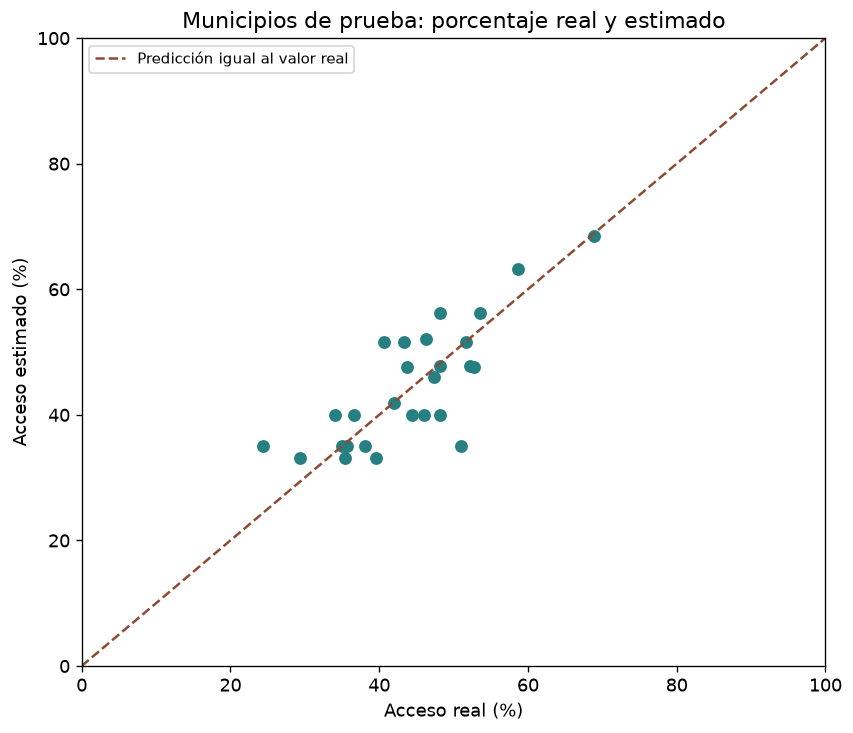

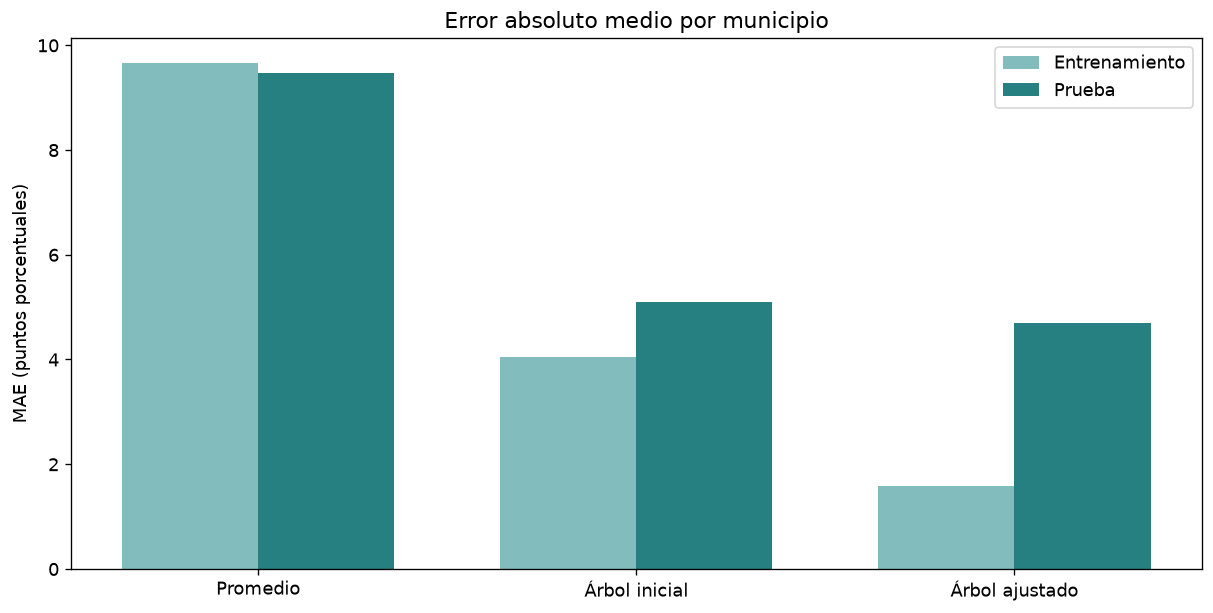

In [9]:
graficos = guardar_resultados(datos, resultado, RAIZ)
display(Image(filename=str(graficos['predicciones']), width=650))
display(Image(filename=str(graficos['errores']), width=850))

La diagonal del gráfico corresponde a predicciones iguales a las tasas reales.
Los puntos más alejados muestran municipios que el árbol estima con mayor error.
Las franjas horizontales se producen porque varios municipios pueden llegar a
una misma hoja y recibir la misma predicción.

In [10]:
display(resultado['predicciones'][['municipio', 'real_pct', 'prediccion_pct',
                                   'baseline_pct', 'error_pp', 'error_absoluto_pp']])

,municipio,real_pct,prediccion_pct,baseline_pct,error_pp,error_absoluto_pp
54,Villa Libertad Licoma,51.042,35.100,51.694,-15.943,15.943
79,Tito Yupanqui,40.706,51.624,51.694,10.918,10.918
25,Ayata,24.327,35.100,51.694,10.772,10.772
17,Nazacara de Pacajes,48.228,39.902,51.694,-8.325,8.325
11,Corocoro,43.345,51.624,51.694,8.279,8.279
5,Achacachi,48.187,56.219,51.694,8.032,8.032
53,Ichoca,39.508,33.051,51.694,-6.457,6.457
66,Ayo Ayo,46.078,39.902,51.694,-6.176,6.176
76,Curva,33.998,39.902,51.694,5.905,5.905
67,Calamarca,46.223,52.082,51.694,5.859,5.859


### 9. Variables importantes

La importancia mide la fracción de reducción del error de entrenamiento
atribuida a cada predictor por este árbol. Su suma es 1 si hubo divisiones.
No equivale a un efecto causal, al signo de un coeficiente o al porcentaje de
hogares que tienen Internet. Los predictores correlacionados pueden repartirse
la importancia, y la clasificación puede cambiar con otra muestra.

,variable,descripcion,importancia
2,pct_celular,Con teléfono celular (%),0.896
0,pct_urbanas,Viviendas urbanas (%),0.047
1,pct_computadora,"Con computadora, laptop o tablet (%)",0.032
3,pct_red_electrica,Con electricidad de red pública (%),0.018
4,pct_3_o_mas_habitaciones,Con 3 o más habitaciones (%),0.005
5,promedio_personas,Personas por vivienda (promedio),0.002


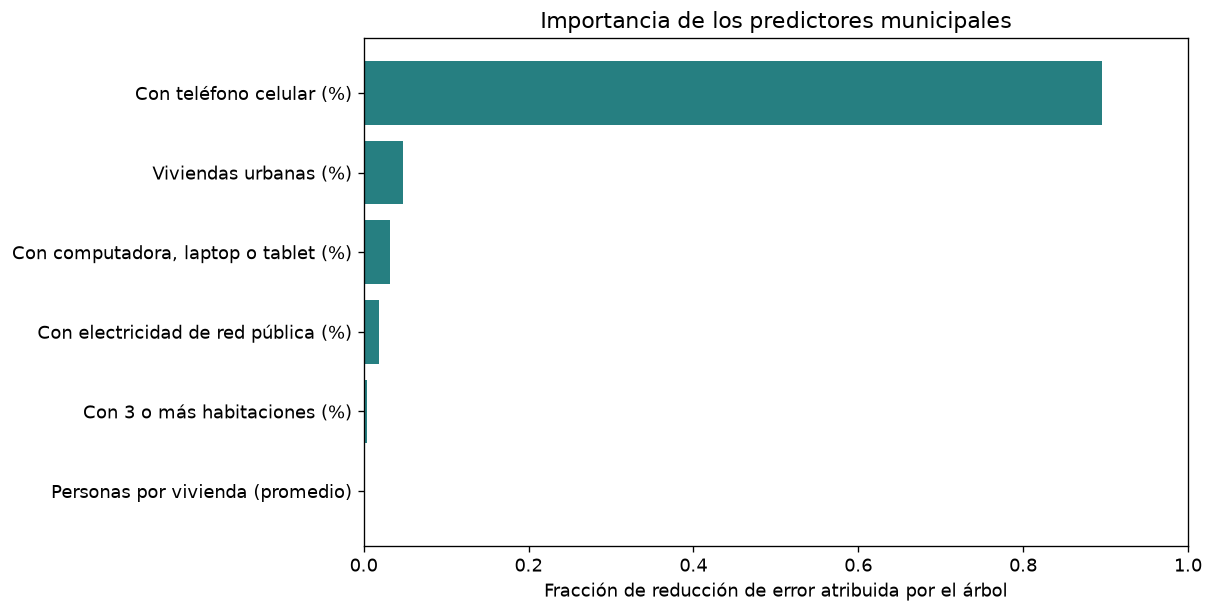

En este ajuste, **Con teléfono celular (%)** recibe la mayor importancia: **89.6 %**. Esto describe las divisiones utilizadas por el árbol. No demuestra que disponer de celular cause el acceso a Internet.

In [11]:
display(resultado['importancias'])
display(Image(filename=str(graficos['importancias']), width=850))
principal = resultado['importancias'].iloc[0]
texto(f'En este ajuste, **{principal["descripcion"]}** recibe la mayor '
      f'importancia: **{principal["importancia"] * 100:.1f} %**. '
      f'Esto describe las divisiones utilizadas por el árbol. No demuestra '
      f'que disponer de celular cause el acceso a Internet.')

### 10. Visualización e interpretación de una ruta

En cada nodo se muestran una condición, el error de las observaciones de
entrenamiento, su cantidad y la media de acceso. En una hoja, esa media es la
predicción numérica. La figura muestra hasta tres niveles para conservar
legibilidad; las reglas completas se exportan en texto.

,profundidad,hojas,nodos
0,7,17,33


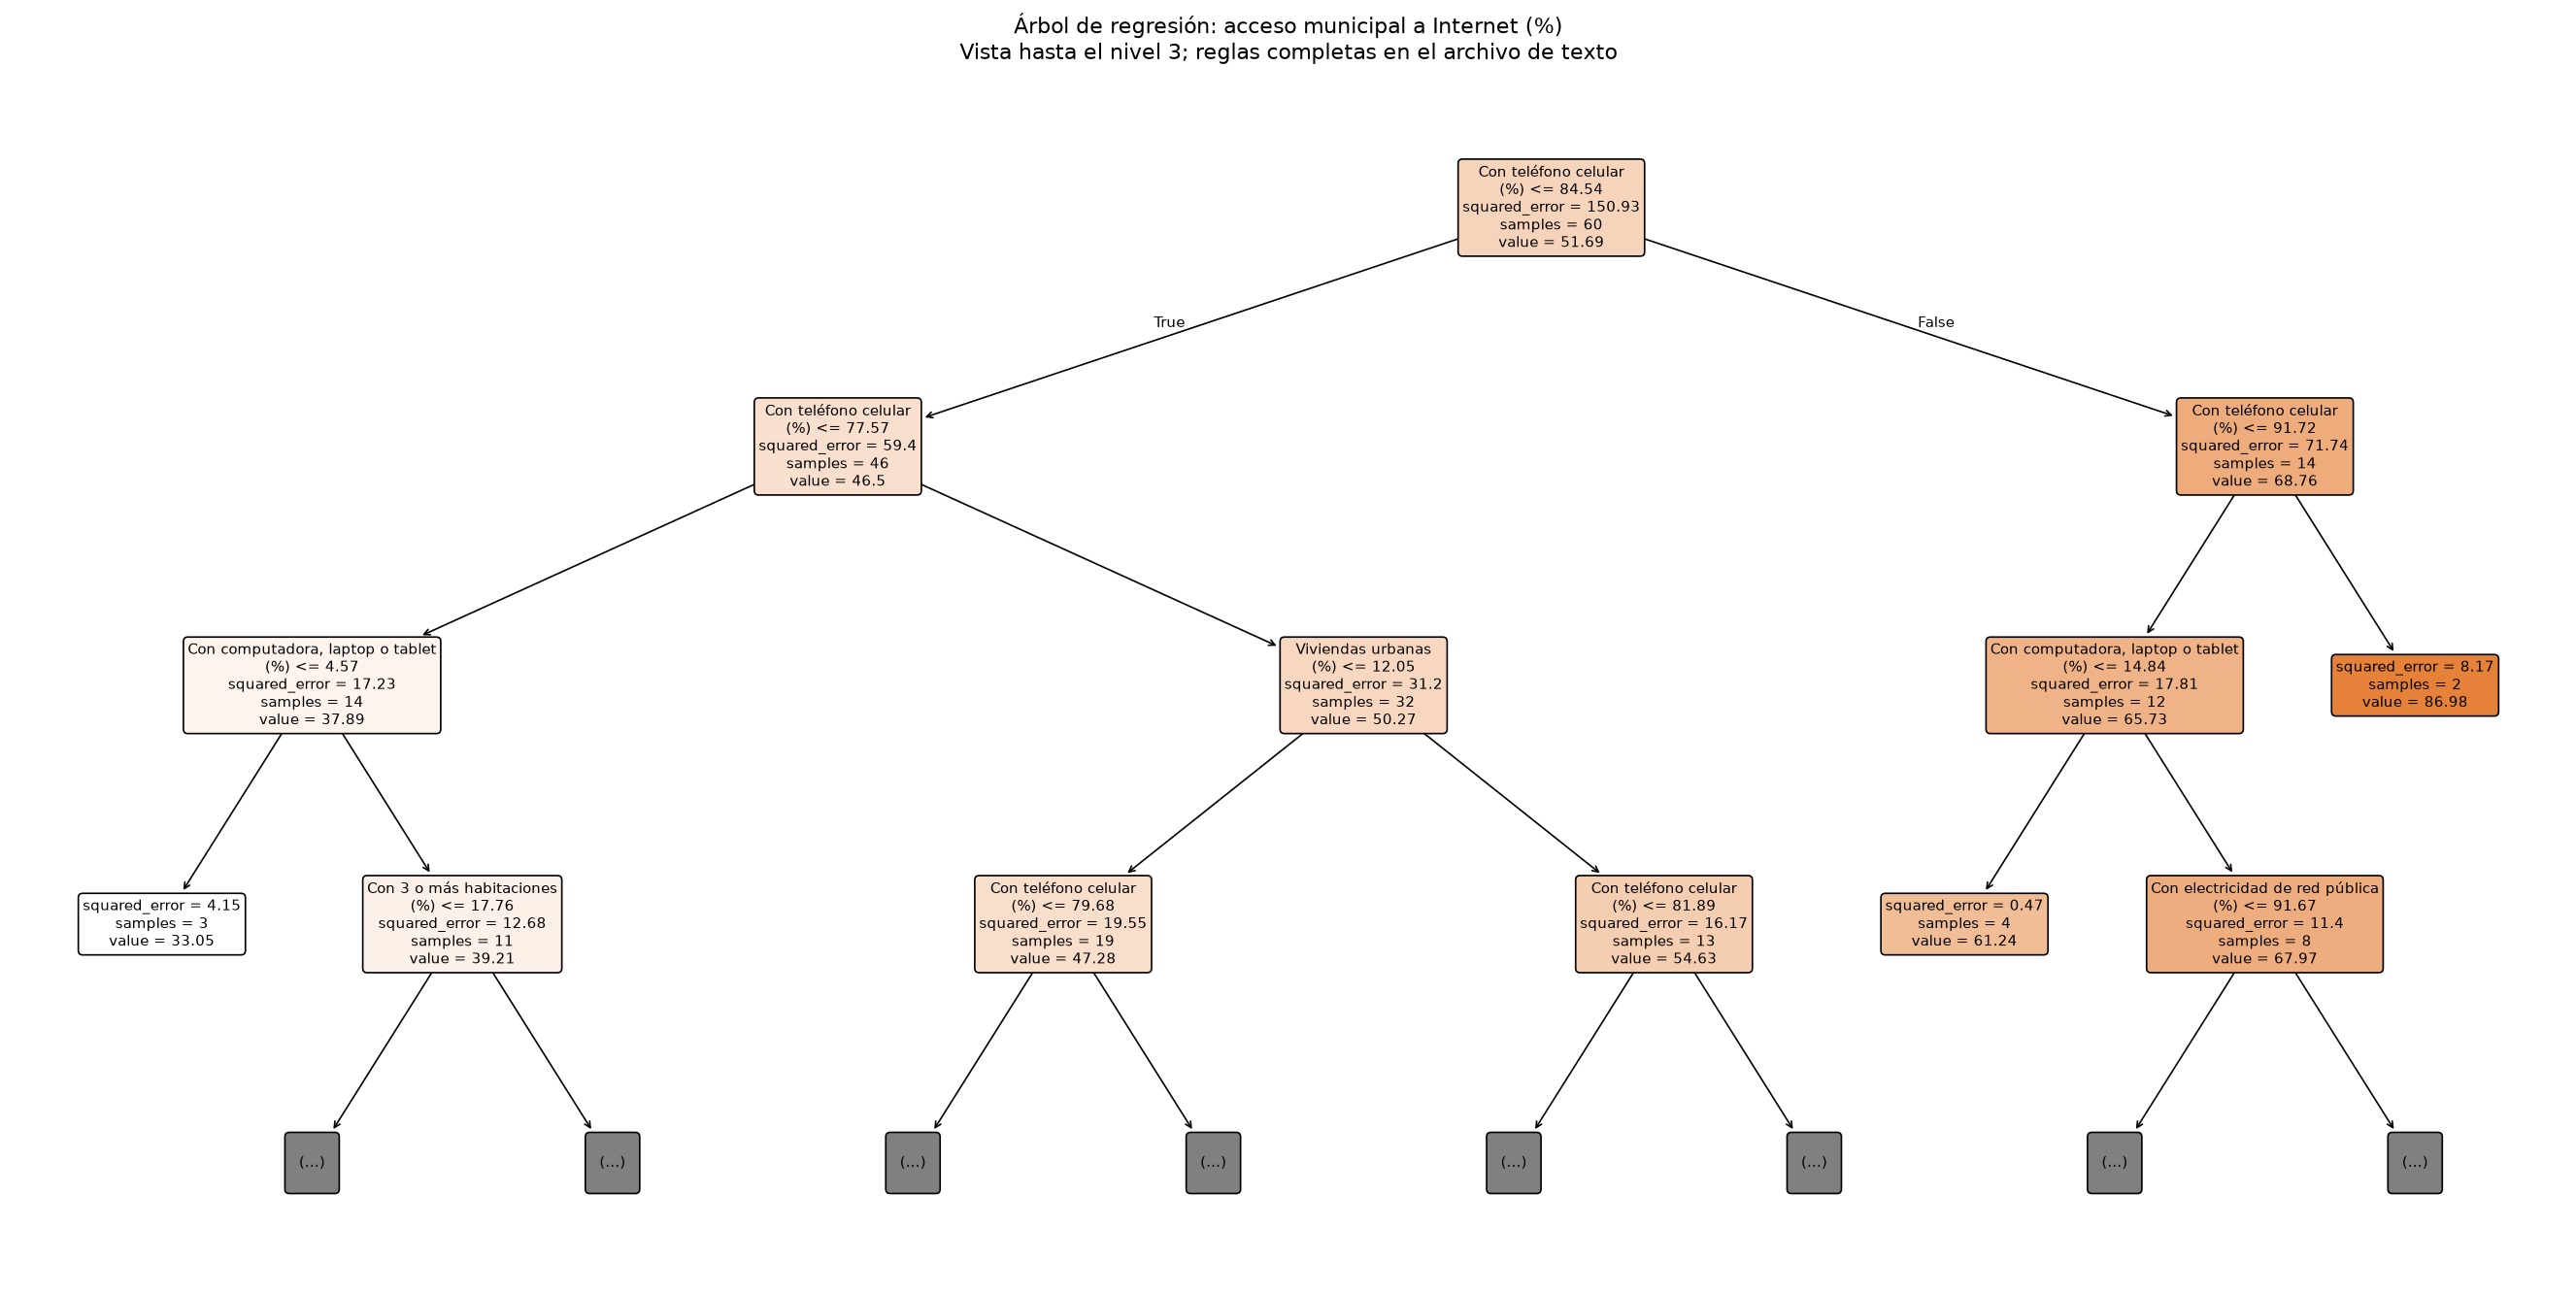

|--- Con teléfono celular (%) <= 84.539
|   |--- Con teléfono celular (%) <= 77.567
|   |   |--- Con computadora, laptop o tablet (%) <= 4.574
|   |   |   |--- value: [33.051]
|   |   |--- Con computadora, laptop o tablet (%) >  4.574
|   |   |   |--- Con 3 o más habitaciones (%) <= 17.763
|   |   |   |   |--- value: [43.275]
|   |   |   |--- Con 3 o más habitaciones (%) >  17.763
|   |   |   |   |--- Con electricidad de red pública (%) <= 72.158
|   |   |   |   |   |--- value: [39.902]
|   |   |   |   |--- Con electricidad de red pública (%) >  72.158
|   |   |   |   |   |--- value: [35.100]
|   |--- Con teléfono celular (%) >  77.567
|   |   |--- Viviendas urbanas (%) <= 12.045
|   |   |   |--- Con teléfono celular (%) <= 79.677
|   |   |   |   |--- value: [41.890]
|   |   |   |--- Con teléfono celular (%) >  79.677
|   |   |   |   |--- Con computadora, laptop o tablet (%) <= 6.413
|   |   |   |   |   |--- value: [46.017]
|   |   |   |   |--- Con computadora, laptop o tablet (%) >  6

In [12]:
display(pd.DataFrame([resultado['resumen']['estructura_arbol']]))
display(Image(filename=str(graficos['arbol']), width=1300))
print((RAIZ / 'outputs/h3_3/reglas_arbol.txt').read_text(encoding='utf-8'))

In [13]:
# Ejemplo reproducible: primer municipio de prueba por código, sin elegirlo por su error.
indice = tabla.loc[X_test.index].sort_values('municipio_codigo').index[0]
municipio = tabla.loc[indice, 'municipio']
ruta, prediccion = explicar_prediccion(modelo, X_test.loc[[indice]])
display(ruta)
texto(f'**{municipio}** sigue las condiciones de la tabla y llega a una hoja '
      f'que estima **{prediccion:.2f} %** de acceso. Su tasa observada es '
      f'**{y_test.loc[indice]:.2f} %**. La hoja resume municipios de entrenamiento; '
      f'el municipio de prueba no intervino en el ajuste.')

,variable,valor_municipal,condicion,umbral
0,Con teléfono celular (%),82.610,≤,84.539
1,Con teléfono celular (%),82.610,>,77.567
2,Viviendas urbanas (%),0.000,≤,12.045
3,Con teléfono celular (%),82.610,>,79.677
4,"Con computadora, laptop o tablet (%)",7.159,>,6.413
5,"Con computadora, laptop o tablet (%)",7.159,≤,11.563
6,Con electricidad de red pública (%),85.194,>,79.616


**Palca** sigue las condiciones de la tabla y llega a una hoja que estima **47.79 %** de acceso. Su tasa observada es **52.16 %**. La hoja resume municipios de entrenamiento; el municipio de prueba no intervino en el ajuste.

### 11. Comprobaciones de reproducibilidad

Se verifica que los municipios de entrenamiento y prueba no se compartan, que
las tasas coincidan con el EDA y que las predicciones del pipeline guardado
coincidan con las del modelo en memoria. La lectura valida las fuentes mediante
SHA-256 antes de construir la tabla.

In [14]:
assert datos.audit['tasas_y_denominadores_coinciden_con_eda']
assert not set(X_train.index).intersection(X_test.index)
assert tabla[TARGET].between(0, 100).all()
assert tabla['municipio_codigo'].is_unique
assert np.isclose(resultado['importancias']['importancia'].sum(), 1)
modelo_guardado = joblib.load(RAIZ / 'outputs/h3_3/arbol_regresion.joblib')
assert np.allclose(modelo_guardado.predict(X_test), modelo.predict(X_test))
texto('**Comprobaciones correctas:** fuentes y tasas del grupo, partición municipal '
      'y predicciones del pipeline guardado.')
display(pd.DataFrame([resultado['resumen']['versiones']]))

**Comprobaciones correctas:** fuentes y tasas del grupo, partición municipal y predicciones del pipeline guardado.

,python,numpy,pandas,scikit_learn,matplotlib
0,3.12.10,2.5.2,3.0.5,1.9.1,3.11.1


### 12. Conclusiones y siguiente mejora

El árbol de regresión permite estudiar el porcentaje municipal de acceso con
predictores del propio censo, manteniendo los denominadores del proyecto.
La comparación con el promedio de entrenamiento y con el árbol inicial permite
cuantificar su aporte. Las cifras siguientes provienen de esta ejecución.

In [15]:
texto(f'1. Se analizaron **{len(tabla)} municipios** a partir de '
      f'**{universo:,} viviendas aplicables**. El acceso departamental fue '
      f'**{tasa_departamental:.2f} %**.\n\n'
      f'2. En prueba, el árbol ajustado obtuvo **MAE {fila_final["test_mae_pp"]:.2f} pp** '
      f'y **R² {fila_final["test_r2"]:.3f}**. La referencia obtuvo '
      f'**MAE {fila_base["test_mae_pp"]:.2f} pp**.\n\n'
      f'3. **{principal["descripcion"]}** fue el predictor con mayor importancia '
      f'en este árbol. Se interpreta como asociación municipal.\n\n'
      f'4. La separación entre error de entrenamiento y prueba y el tamaño '
      f'reducido de la tabla limitan la confianza en nuevas predicciones.')

1. Se analizaron **87 municipios** a partir de **1,069,838 viviendas aplicables**. El acceso departamental fue **69.95 %**.

2. En prueba, el árbol ajustado obtuvo **MAE 4.69 pp** y **R² 0.570**. La referencia obtuvo **MAE 9.47 pp**.

3. **Con teléfono celular (%)** fue el predictor con mayor importancia en este árbol. Se interpreta como asociación municipal.

4. La separación entre error de entrenamiento y prueba y el tamaño reducido de la tabla limitan la confianza en nuevas predicciones.

Como mejora futura, se propone obtener un conjunto de evaluación externo y
comparar árboles más simples mediante validación anidada, o repetir particiones
municipales con un protocolo definido antes de examinar sus resultados. Una
validación que reserve provincias completas permitiría estudiar transferencia
geográfica. Estas pruebas no se presentan como mejoras ya obtenidas.

Para apoyar decisiones reales harían falta datos adicionales de cobertura,
calidad y costo. Los 87 municipios de una sola gestión no permiten estimar una
tendencia temporal ni atribuir causalidad. La no respuesta permanece como una
fuente de incertidumbre.

**Relación con la evaluación grupal:** la consigna publicada por el docente pide
evidencia de clasificación. Esa evidencia sigue en H3_1 y H3_2; esta práctica
de regresión amplía el proyecto y no sustituye sus métricas de clasificación.